# Classification Models — A Complete Guide

**Author:** Shivani Bokka  
**Datasets:** Breast Cancer Wisconsin (binary) · Wine Quality (multi-class)  
**Goal:** Classify samples into categories using a variety of models

---

## What Is This Notebook About?

This notebook is a **comprehensive guide to classification models**. Each section explains the core intuition in plain, everyday language, before implementing the model in Python.

Whether you're a student learning machine learning, or an employer reviewing this portfolio — every model here includes:
- A plain-English explanation of how it works
- The math behind it (kept as simple as possible)
- Code with visualizations
- When to use it (and when not to)

---

## What Is Classification?

In **regression**, we predict a number (like a house price). In **classification**, we predict a **category** — like:
- Is this tumor *malignant* or *benign*?
- Is this email *spam* or *not spam*?
- Which type of wine is this — *class A, B, or C*?

> **Simple analogy:** You're a doctor looking at a scan. You're not predicting the size of the tumor in millimeters — you're deciding: *is this cancerous or not?* That's classification.

---

## Dataset Strategy

| Dataset | Type | Used For |
|---------|------|----------|
| **Breast Cancer Wisconsin** | Binary (malignant/benign) | Naive Bayes, SVM, Gradient Boosting, XGBoost |
| **Wine Dataset** | Multi-class (3 wine types) | LDA, QDA, KNN |

---

## Models Covered

| # | Model | Dataset Used |
|---|-------|--------------|
| 1 | Linear Discriminant Analysis (LDA) | Wine |
| 2 | Quadratic Discriminant Analysis (QDA) | Wine |
| 3 | Gaussian Naive Bayes | Breast Cancer |
| 4 | K-Nearest Neighbors (KNN) | Wine |
| 5 | Support Vector Machine (SVM) | Breast Cancer |
| 6 | Gradient Boosting (GBM) | Breast Cancer |
| 7 | XGBoost | Breast Cancer |

---

## Step 1 — Imports and Setup

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Classification Models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost")

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


---

## Step 2 — Load Datasets

### Dataset A: Breast Cancer Wisconsin

This dataset contains measurements from digitized images of fine needle aspirate (FNA) of breast masses. Each sample describes characteristics of cell nuclei present in the image.

- **569 samples**, **30 numeric features**
- **Target:** 0 = Malignant (cancerous), 1 = Benign (non-cancerous)

### Dataset B: Wine Dataset

This dataset is the result of a chemical analysis of wines grown in the same region in Italy but derived from **three different cultivars**.

- **178 samples**, **13 numeric features** (alcohol, malic acid, ash, etc.)
- **Target:** 3 wine classes (0, 1, 2)

In [101]:
# --- Breast Cancer Dataset ---
bc = load_breast_cancer(as_frame=True)
df_bc = bc.frame

print("=== Breast Cancer Dataset ===")
print(f"Shape: {df_bc.shape}")
print(f"Classes: {bc.target_names}")
print(f"Class distribution:\n{df_bc['target'].value_counts()}")
df_bc.head(3)

=== Breast Cancer Dataset ===
Shape: (569, 31)
Classes: ['malignant' 'benign']
Class distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0


In [102]:
# --- Wine Dataset ---
wine = load_wine(as_frame=True)
df_wine = wine.frame

print("=== Wine Dataset ===")
print(f"Shape: {df_wine.shape}")
print(f"Classes: {wine.target_names}")
print(f"Class distribution:\n{df_wine['target'].value_counts()}")
df_wine.head(3)

=== Wine Dataset ===
Shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']
Class distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065.0000,0
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050.0000,0
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185.0000,0


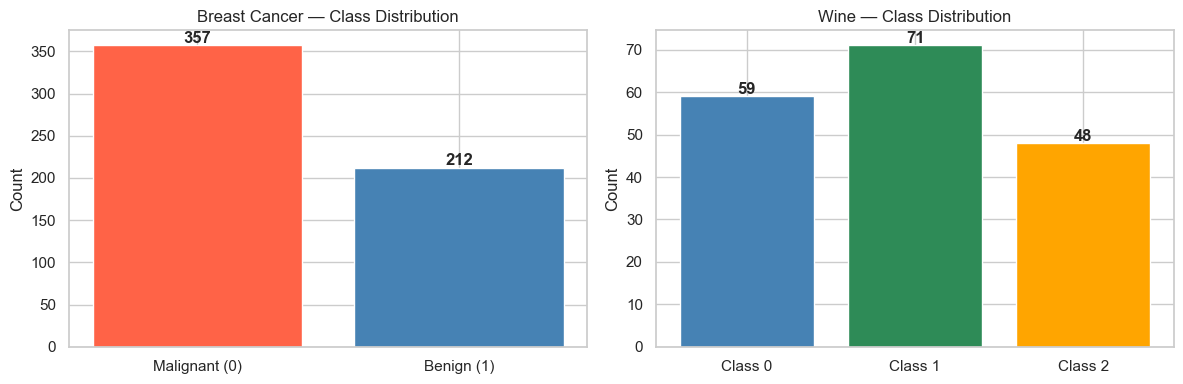

In [103]:
# Visualize class distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Breast Cancer
bc_counts = df_bc['target'].value_counts()
axes[0].bar(['Malignant (0)', 'Benign (1)'], bc_counts.values, color=['tomato', 'steelblue'])
axes[0].set_title('Breast Cancer — Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(bc_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Wine
wine_counts = df_wine['target'].value_counts().sort_index()
axes[1].bar(['Class 0', 'Class 1', 'Class 2'], wine_counts.values, color=['steelblue', 'seagreen', 'orange'])
axes[1].set_title('Wine — Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(wine_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### How to Read This Chart: Class Distribution Bar Charts

These two **bar charts** show how many samples belong to each class in our two datasets.

**Left chart — Breast Cancer:**
- **Red bar (Malignant):** How many tumors in the dataset are cancerous.
- **Blue bar (Benign):** How many tumors are non-cancerous.
- The number on top of each bar is the exact count.

**Right chart — Wine:**
- **Three bars** represent the three wine cultivar classes.
- The number on top of each bar is the exact count.

**Why class distribution matters:**
- If one bar is much taller than the other(s), the dataset is **imbalanced** — the model will see one class far more often and may become biased toward predicting it.
- In the Breast Cancer dataset, there are more benign samples than malignant. In real medical settings, missing a malignant case (false negative) is far more dangerous than a false alarm.
- In the Wine dataset, classes are relatively **balanced** — this makes classification easier and metrics like accuracy more trustworthy.

---

## Step 3 — Prepare Both Datasets

In [104]:
# --- Breast Cancer ---
X_bc = df_bc.drop('target', axis=1)
y_bc = df_bc['target']

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()
X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
X_bc_test_scaled  = scaler_bc.transform(X_bc_test)

# --- Wine ---
X_wine = df_wine.drop('target', axis=1)
y_wine = df_wine['target']

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

scaler_wine = StandardScaler()
X_wine_train_scaled = scaler_wine.fit_transform(X_wine_train)
X_wine_test_scaled  = scaler_wine.transform(X_wine_test)

print("Breast Cancer — Train:", X_bc_train.shape, "| Test:", X_bc_test.shape)
print("Wine          — Train:", X_wine_train.shape, "| Test:", X_wine_test.shape)

Breast Cancer — Train: (455, 30) | Test: (114, 30)
Wine          — Train: (142, 13) | Test: (36, 13)


---

## Evaluation Helpers

We'll track all model results and use two key evaluation tools:

- **Confusion Matrix** — shows how many predictions were correct/incorrect for each class
- **Classification Report** — shows precision, recall, and F1-score per class
- **ROC-AUC** — for binary classifiers, measures how well the model separates the two classes

In [105]:
clf_results = {}

def evaluate_classifier(name, model, X_train, X_test, y_train, y_test,
                         target_names=None, plot_cm=True, binary=False):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Cross-validated accuracy
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    clf_results[name] = {
        'Accuracy': acc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }

    print(f"--- {name} ---")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  CV Accuracy   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=target_names))

    if plot_cm:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Confusion Matrix
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, display_labels=target_names,
            colorbar=False, ax=axes[0], cmap='Blues'
        )
        axes[0].set_title(f'{name}\nConfusion Matrix')

        # ROC Curve (binary only)
        if binary and hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            clf_results[name]['AUC'] = auc
            axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.3f}')
            axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
            axes[1].set_xlabel('False Positive Rate')
            axes[1].set_ylabel('True Positive Rate')
            axes[1].set_title(f'{name}\nROC Curve')
            axes[1].legend()
        else:
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return y_pred

---

## What Is a Discriminant?

Before diving into LDA and QDA, it helps to understand what a **discriminant** actually is.

A **discriminant** is a mathematical scoring function that takes a data point as input and outputs a number. You compute this score for each class, and then **assign the data point to whichever class gives the highest score**.

> **Plain English:** Imagine you are a customs officer deciding whether a passenger belongs to group A (tourist) or group B (business traveller). You look at several clues — their luggage, clothes, documents — and mentally score them for each group. Whichever group scores higher is your classification. The scoring formula is the discriminant.

Both LDA and QDA work by computing a **discriminant score** for each class and picking the winner. The difference is in how that score is calculated — LDA uses a simpler formula (linear), QDA uses a richer one (quadratic).

---

# 1. Linear Discriminant Analysis (LDA)

**Dataset: Wine (Multi-class)**

## What Is It?

LDA is a **dimensionality reduction + classification** technique. It finds the **linear combination of features** that best separates the classes.

**The Core Idea:**  
Imagine you have two groups of data points scattered on a 2D plane. LDA finds the best **axis** to project all points onto so that:
1. Points within the same class are as **close together** as possible
2. Points from different classes are as **far apart** as possible

> **Real-world analogy:** You're sorting red and blue balls by rolling them down different ramps. LDA finds the ramp angle that makes red balls land in one pile and blue balls in another.

## What Is a Covariance Matrix?

The covariance matrix is central to how LDA (and QDA) work, so it is worth understanding before looking at the formula.

A **covariance matrix** captures two things about your features:
- **Variance** (on the diagonal): how much each individual feature varies. A large variance means that feature has a wide spread of values.
- **Covariance** (off the diagonal): how much two features move together. If income and house price both go up together, their covariance is positive.

For a dataset with 3 features (A, B, C), the covariance matrix looks like:

$$\Sigma = \begin{pmatrix} \text{Var}(A) & \text{Cov}(A,B) & \text{Cov}(A,C) \\\\ \text{Cov}(B,A) & \text{Var}(B) & \text{Cov}(B,C) \\\\ \text{Cov}(C,A) & \text{Cov}(C,B) & \text{Var}(C) \end{pmatrix}$$

> **Why does LDA care?** LDA assumes all classes have the **same** covariance matrix — meaning all classes spread out in the same shape, just located at different centres. QDA relaxes this and allows each class its own covariance matrix.

## The LDA Formula

LDA assigns a new point $x$ to the class $k$ that maximises the **linear discriminant score**:

$$\delta_k(x) = x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log(\pi_k)$$

Where:
- $x$ = the new data point (a vector of feature values)
- $\mu_k$ = the **mean vector** of class $k$ — the average value of each feature for all samples in that class
- $\Sigma$ = the **shared covariance matrix** (same for all classes)
- $\Sigma^{-1}$ = the inverse of the covariance matrix
- $\pi_k$ = the **prior probability** of class $k$ — the proportion of training samples in that class

**In plain English:** For each class, LDA scores the new point based on how close it is to that class's centre, adjusted for how the data is spread and how common that class is. The class with the highest score wins. Because the formula is linear in $x$, the decision boundary between two classes is always a **straight line**.

## Key Assumptions

LDA assumes:
1. Each class has a **Gaussian (normal) distribution**
2. All classes share the **same covariance matrix** $\Sigma$

## When to Use LDA?
- Multi-class classification with **well-separated classes**
- When you also want **dimensionality reduction**
- When features roughly follow a Gaussian distribution

--- LDA ---
  Test Accuracy : 0.9444
  CV Accuracy   : 0.9929 +/- 0.0143

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



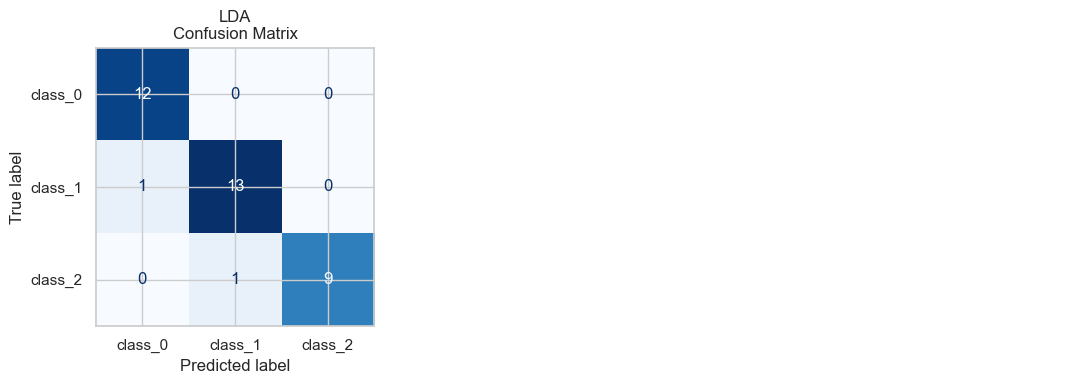

In [106]:
lda = LinearDiscriminantAnalysis()
y_pred_lda = evaluate_classifier(
    'LDA', lda,
    X_wine_train_scaled, X_wine_test_scaled,
    y_wine_train, y_wine_test,
    target_names=wine.target_names
)

### How to Read These Charts: Confusion Matrix

The **confusion matrix** is one of the most important tools in classification. It's a grid that shows exactly what the model got right and wrong.

- **Rows** = the actual (true) class of each sample.
- **Columns** = what the model *predicted* the class to be.
- **Diagonal cells (top-left to bottom-right)** = correct predictions. Darker blue = more correct predictions.
- **Off-diagonal cells** = mistakes. For example, if row is 'class_0' and column is 'class_1', those are samples that were actually class 0 but the model incorrectly predicted class 1.

**What to look for:**
- A **good model** has large numbers on the diagonal and small (or zero) numbers everywhere else.
- **Darker squares on the diagonal** = the model is doing well for that class.
- Any bright off-diagonal square highlights where the model consistently confuses two classes.

**For the classification report (printed above the chart):**
- **Precision** = of all the times the model predicted class X, what fraction were actually class X? High precision = few false alarms.
- **Recall** = of all the actual class X samples, what fraction did the model correctly identify? High recall = few misses.
- **F1-score** = a single balanced score combining precision and recall. Ranges from 0 to 1; higher is better.
- **Support** = how many samples of that class exist in the test set.

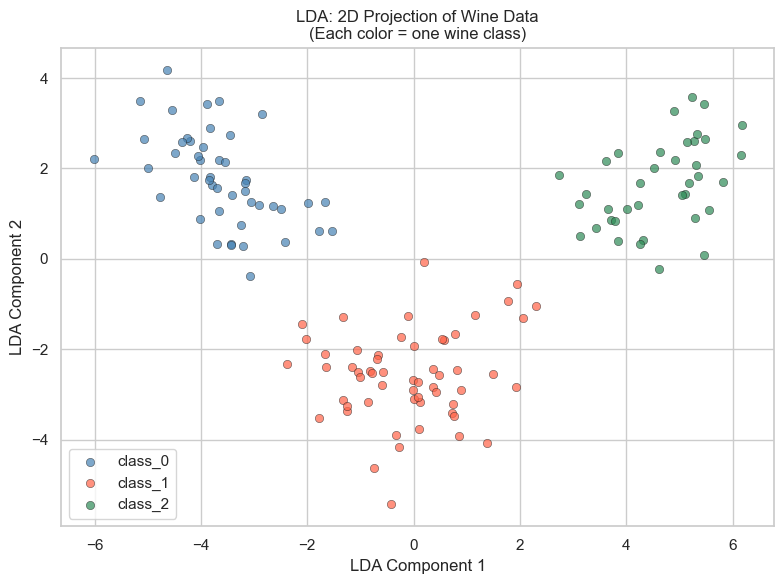


Notice how well the three wine classes are separated in 2D — LDA found the best projection.


In [107]:
# Visualize LDA projection (2D)
lda_viz = LinearDiscriminantAnalysis(n_components=2)
X_lda_2d = lda_viz.fit_transform(X_wine_train_scaled, y_wine_train)

colors = ['steelblue', 'tomato', 'seagreen']
plt.figure(figsize=(8, 6))
for cls, col, name in zip([0, 1, 2], colors, wine.target_names):
    mask = y_wine_train == cls
    plt.scatter(X_lda_2d[mask, 0], X_lda_2d[mask, 1],
                label=name, color=col, alpha=0.7, edgecolors='k', linewidths=0.4)

plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('LDA: 2D Projection of Wine Data\n(Each color = one wine class)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nNotice how well the three wine classes are separated in 2D — LDA found the best projection.")

### How to Read This Chart: LDA 2D Projection

This **scatter plot** visualizes LDA's most powerful feature — it can **compress many dimensions into just 2** while keeping the classes as separate as possible.

- **Each dot** is one wine sample from the training set.
- **The color** of each dot tells you which wine cultivar it truly belongs to.
- **The x-axis (LDA Component 1)** and **y-axis (LDA Component 2)** are not original features — they are new axes created by LDA that maximize the separation between classes.

**What to look for:**
- If the **three colored clusters are clearly separated** with little overlap, LDA is doing an excellent job.
- If the clusters overlap heavily, the classes are harder to separate and the model may struggle.
- Notice that all 13 original wine features have been reduced to just 2 components — yet the classes are still well separated. This is the power of LDA.

> **Why this matters:** LDA can be used both to classify AND to visualize high-dimensional data in 2D, making it extremely useful for exploratory data analysis.

---

# 2. Quadratic Discriminant Analysis (QDA)

**Dataset: Wine (Multi-class)**

## What Is It?

QDA is the **more flexible version of LDA**. The key difference: QDA does **not assume** all classes share the same covariance matrix. Each class can have its own spread and shape.

In LDA, decision boundaries are **straight lines**. In QDA, they are **curves**.

> **Real-world analogy:**  
> LDA fits all wine glasses with the same circular base (same covariance). QDA allows each glass to have a different base shape — more realistic but requires more data to estimate.

## The QDA Formula

QDA assigns a new point $x$ to the class $k$ that maximises the **quadratic discriminant score**:

$$\delta_k(x) = -\frac{1}{2} \log|\Sigma_k| - \frac{1}{2}(x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) + \log(\pi_k)$$

Where:
- $x$ = the new data point
- $\mu_k$ = the mean vector of class $k$
- $\Sigma_k$ = the **covariance matrix of class $k$ specifically** (each class has its own — this is the key difference from LDA)
- $|\Sigma_k|$ = the determinant of the covariance matrix (a single number representing its overall scale)
- $\pi_k$ = the prior probability of class $k$

**Comparing QDA to LDA:**
- In LDA, all classes share one $\Sigma$ — the formula simplifies to a linear function of $x$.
- In QDA, each class has its own $\Sigma_k$ — the term $(x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)$ is quadratic in $x$, which is why the decision boundary becomes a curve.
- The $-\frac{1}{2}\log|\Sigma_k|$ term penalises classes with very large or spread-out covariance matrices — it acts as a natural regularizer.

**In plain English:** QDA measures how far the new point is from each class centre, but now it accounts for the fact that each class has its own unique shape and spread. A class that is very spread out gets penalised slightly. Because the distance calculation is quadratic (involves squared terms), the boundary between classes can be a curve rather than a straight line.

## LDA vs QDA — When to Choose Which?

| Situation | Choose |
|-----------|--------|
| Classes have **similar spread/shape** | LDA |
| Classes have **different spread/shape** | QDA |
| **Small dataset** | LDA (fewer parameters to estimate) |
| **Large dataset** | QDA (can afford to estimate per-class covariance) |

--- QDA ---
  Test Accuracy : 1.0000
  CV Accuracy   : 0.9788 +/- 0.0173

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



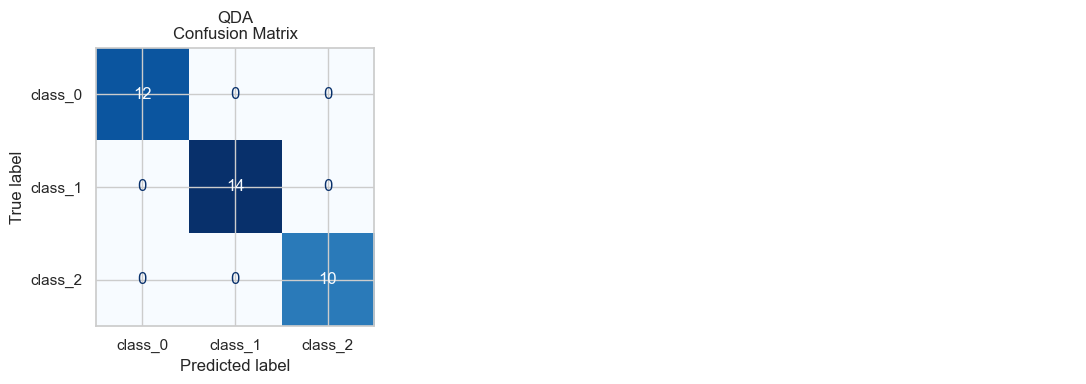

In [108]:
qda = QuadraticDiscriminantAnalysis()
y_pred_qda = evaluate_classifier(
    'QDA', qda,
    X_wine_train_scaled, X_wine_test_scaled,
    y_wine_train, y_wine_test,
    target_names=wine.target_names
)

### How to Read These Charts: QDA Confusion Matrix

Same confusion matrix format as LDA — rows are actual classes, columns are predicted classes, diagonal = correct predictions.

**Comparing QDA to LDA:**
- If the QDA confusion matrix has **fewer off-diagonal values** than LDA, QDA is performing better — its curved boundaries are fitting the wine data more accurately.
- If they are similar, the linear boundaries of LDA are already sufficient.
- Pay attention to which class (which row) each model struggles with most — this reveals where the boundaries between classes are most ambiguous.

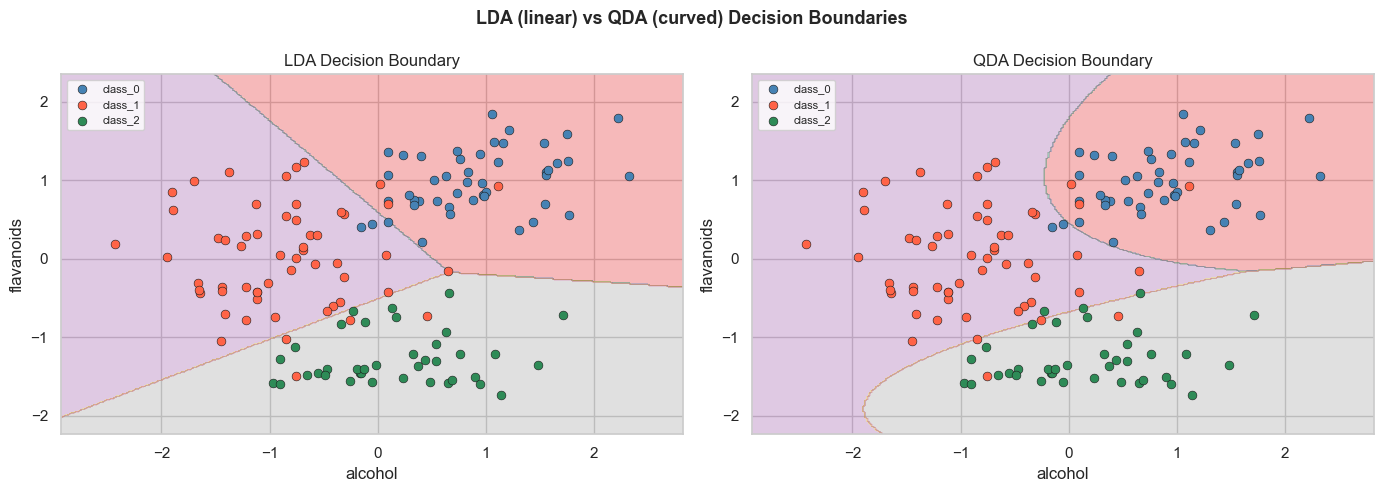

In [109]:
# Compare LDA vs QDA decision boundaries on 2 features
feat_idx = [0, 6]  # Alcohol and Flavanoids
feat_names = [wine.feature_names[i] for i in feat_idx]

X_2feat_train = X_wine_train_scaled[:, feat_idx]
X_2feat_test  = X_wine_test_scaled[:, feat_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, clf, title in zip(axes, [LinearDiscriminantAnalysis(), QuadraticDiscriminantAnalysis()], ['LDA', 'QDA']):
    clf.fit(X_2feat_train, y_wine_train)

    x_min, x_max = X_2feat_train[:, 0].min() - 0.5, X_2feat_train[:, 0].max() + 0.5
    y_min, y_max = X_2feat_train[:, 1].min() - 0.5, X_2feat_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    for cls, col in zip([0, 1, 2], ['steelblue', 'tomato', 'seagreen']):
        mask = y_wine_train == cls
        ax.scatter(X_2feat_train[mask, 0], X_2feat_train[mask, 1],
                   color=col, edgecolors='k', linewidths=0.4, s=40,
                   label=wine.target_names[cls])
    ax.set_title(f'{title} Decision Boundary')
    ax.set_xlabel(feat_names[0])
    ax.set_ylabel(feat_names[1])
    ax.legend(fontsize=8)

plt.suptitle('LDA (linear) vs QDA (curved) Decision Boundaries', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Decision Boundaries

This **side-by-side comparison** is one of the most visually intuitive charts in machine learning.

- **Each dot** is a wine sample, colored by its true class.
- **The background color** shows what the model predicts for any point in that region — if you dropped a new wine sample anywhere on the chart, the background color tells you which class the model would assign it.
- **The edges where background colors meet** are the **decision boundaries** — where the model changes its prediction.

**LDA (left chart):**
- The boundaries between the colored regions are **straight lines**. LDA always produces linear (straight) boundaries.

**QDA (right chart):**
- The boundaries are **curved lines**. QDA bends and curves the boundaries to better fit the actual shape of each class.

**What to look for:**
- Do the colored regions match where the dots of that color actually are? If yes, the boundaries are in the right place.
- Are there dots sitting inside the wrong-colored region? Those are misclassified samples.
- Does the QDA's curved boundary capture the class shapes better than LDA's straight lines?

---

# 3. Gaussian Naive Bayes

**Dataset: Breast Cancer (Binary)**

## What Is It?

Naive Bayes is a **probabilistic classifier** based on **Bayes' Theorem**. The "Gaussian" part means it assumes each feature follows a **normal (bell-curve) distribution** within each class.

> **Real-world analogy:** Diagnosing a disease. You know how common the disease is in general (prior) AND how likely someone with the disease is to show these specific symptoms. Naive Bayes combines both to give a probability of having the disease.

## Why "Naive"?

It assumes all features are **independent** of each other — which is rarely true, but the model still works surprisingly well.

## When to Use Naive Bayes?
- **Fast, simple baseline** classifier
- When features are roughly **independent**
- When you want **probability estimates** alongside predictions

--- Gaussian Naive Bayes ---
  Test Accuracy : 0.9298
  CV Accuracy   : 0.9319 +/- 0.0044

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



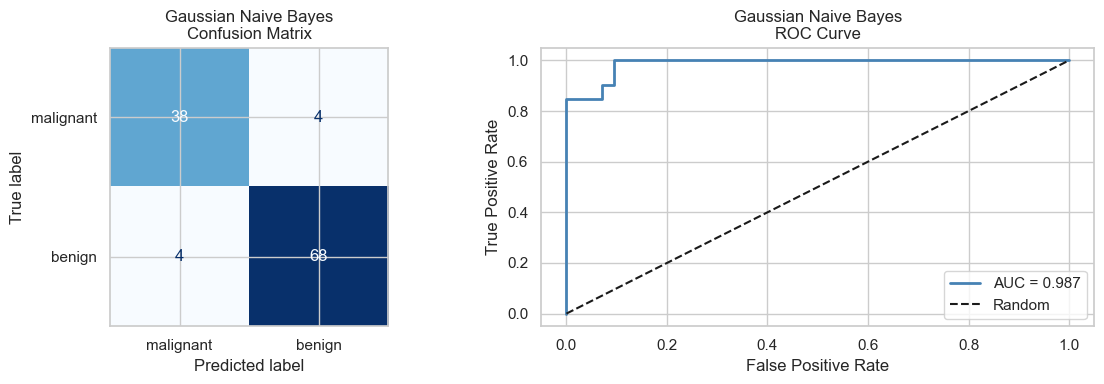

In [110]:
gnb = GaussianNB()
y_pred_gnb = evaluate_classifier(
    'Gaussian Naive Bayes', gnb,
    X_bc_train_scaled, X_bc_test_scaled,
    y_bc_train, y_bc_test,
    target_names=bc.target_names,
    binary=True
)

### How to Read These Charts: Confusion Matrix + ROC Curve

**Left — Confusion Matrix (2x2 for binary classification):**

For binary classification (malignant vs benign), there are four special cells:
- **Top-left (True Negative):** Model said benign AND it really was benign. Correct.
- **Top-right (False Positive):** Model said malignant BUT it was benign. A false alarm.
- **Bottom-left (False Negative):** Model said benign BUT it was malignant. **Dangerous** — a missed cancer.
- **Bottom-right (True Positive):** Model said malignant AND it really was malignant. Correct.

**Right — ROC Curve:**

The **ROC curve** shows how good the model is at distinguishing between the two classes across all possible thresholds.

- **x-axis** = False Positive Rate — how often does the model raise a false alarm?
- **y-axis** = True Positive Rate (Recall/Sensitivity) — how often does it correctly catch a real cancer?
- **Black dashed diagonal** = a random coin flip. A model with no skill sits on this line.
- **Blue curve** = your model. The further it bulges toward the top-left corner, the better.
- **AUC** = Area Under the Curve. Ranges from 0.5 (random) to 1.0 (perfect).

**What to look for:**
- An AUC above 0.9 is excellent. Above 0.7 is acceptable. Near 0.5 means the model is no better than random guessing.
- In medical applications, you want the curve pushed toward the top-left — catching as many true cancers while minimizing false alarms.

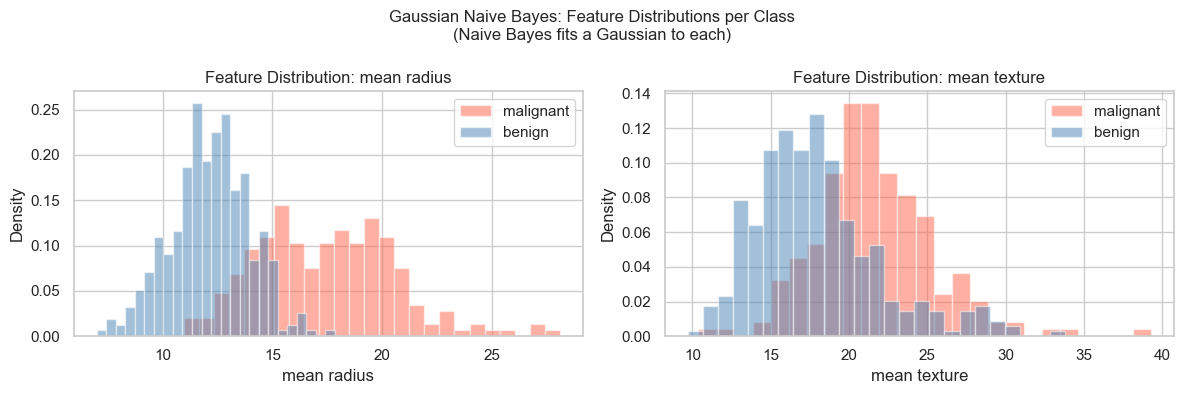

In [111]:
# Visualize the learned Gaussian distributions for top 2 features
top_features = ['mean radius', 'mean texture']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat in zip(axes, top_features):
    for cls, name, color in zip([0, 1], bc.target_names, ['tomato', 'steelblue']):
        vals = df_bc[df_bc['target'] == cls][feat]
        ax.hist(vals, bins=25, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(f'Feature Distribution: {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Gaussian Naive Bayes: Feature Distributions per Class\n(Naive Bayes fits a Gaussian to each)', fontsize=12)
plt.tight_layout()
plt.show()

### How to Read This Chart: Feature Distributions per Class

These **overlapping histograms** show why Gaussian Naive Bayes works the way it does.

- **The x-axis** is the value of the feature (e.g., mean radius of cell nuclei).
- **The y-axis** is the density — how frequently that value occurs within each class.
- **Red bars** = the distribution of this feature for malignant tumors.
- **Blue bars** = the distribution for benign tumors.

**What to look for:**
- When the **red and blue distributions are well separated** (little overlap), this feature is highly informative — it alone can largely distinguish malignant from benign.
- When they **overlap heavily**, this feature alone can't reliably separate the classes, but still contributes in combination with others.
- The Gaussian Naive Bayes model fits a bell curve (Gaussian) to each colored distribution and uses those curves to compute probabilities.

> **Intuition:** If a new patient's "mean radius" falls squarely in the red zone (where malignant cases cluster), the model will assign a high probability of malignancy.

---

# 4. K-Nearest Neighbors Classification (KNN)

**Dataset: Wine (Multi-class)**

## What Is It?

KNN classifies a new data point by looking at its **K nearest neighbors** in the training data and taking a **majority vote**.

> **Real-world analogy:** You're at a party and don't know what music is playing. You ask the 5 people nearest to you — 4 say "jazz", 1 says "classical". You conclude it's jazz. That's KNN.

## When to Use KNN Classifier?
- When **no assumptions** about data distribution are needed
- **Small to medium datasets** where speed isn't critical
- When **local patterns** matter more than global ones

--- KNN Classifier (k=7) ---
  Test Accuracy : 1.0000
  CV Accuracy   : 0.9579 +/- 0.0405

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



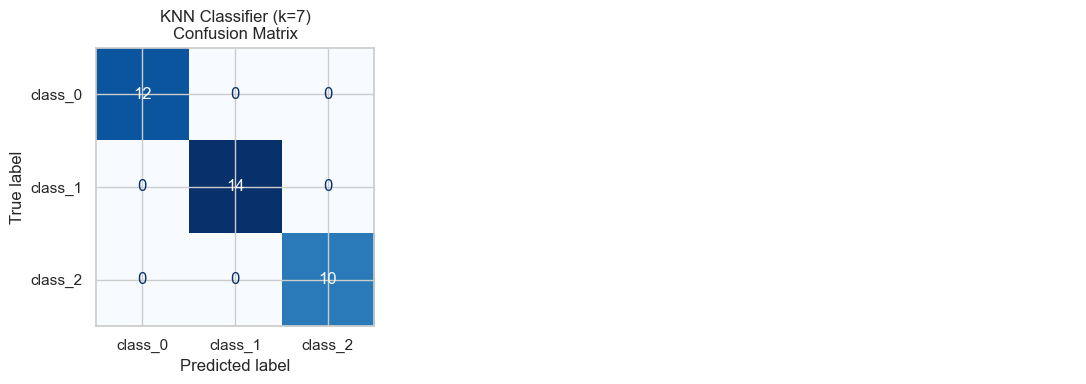

In [112]:
knn_clf = KNeighborsClassifier(n_neighbors=7)
y_pred_knn = evaluate_classifier(
    'KNN Classifier (k=7)', knn_clf,
    X_wine_train_scaled, X_wine_test_scaled,
    y_wine_train, y_wine_test,
    target_names=wine.target_names
)

### How to Read These Charts: KNN Confusion Matrix

Same 3x3 confusion matrix format for the three wine classes.

**What to look for:**
- Compare this matrix to LDA and QDA — does KNN make more or fewer mistakes?
- Which class does KNN most often confuse with another? This could indicate those two classes have very similar chemical profiles.
- Since KNN has no built-in knowledge of class structure (it just uses distance), it may struggle when two classes overlap closely in feature space.

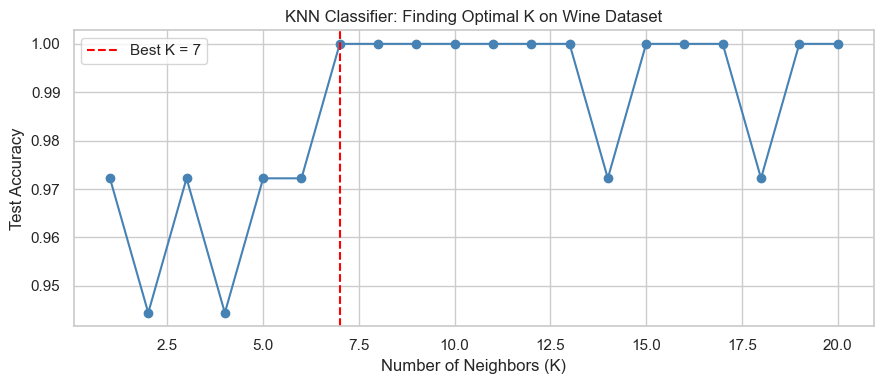

Best K = 7, Accuracy = 1.0000


In [113]:
# Find optimal K
k_values = range(1, 21)
acc_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_wine_train_scaled, y_wine_train)
    acc_scores.append(accuracy_score(y_wine_test, knn_k.predict(X_wine_test_scaled)))

best_k = k_values[np.argmax(acc_scores)]

plt.figure(figsize=(9, 4))
plt.plot(k_values, acc_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.title('KNN Classifier: Finding Optimal K on Wine Dataset')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K = {best_k}, Accuracy = {max(acc_scores):.4f}")

### How to Read This Chart: Finding Optimal K for Classification

This **line chart** shows how classification accuracy changes as we try different values of K.

- **x-axis** = number of neighbors K (from 1 to 20).
- **y-axis** = test accuracy — higher is better (maximum 1.0 = 100%).
- **Red dashed line** = marks the K with the highest accuracy.

**What to look for:**
- At **K=1**, the model memorizes training data exactly — this can cause overfitting and fluctuating test accuracy.
- As K increases, accuracy generally **stabilizes** but may drop as the model averages over too many dissimilar neighbors.
- The **peak of the curve** is your best K for this dataset.
- A **flat curve** means the model is relatively insensitive to K — any value in that range works well.
- A **jagged, unstable curve** (especially at low K) means the model is sensitive to which specific neighbors it picks.

> **Takeaway:** Always search for the best K instead of using defaults. For small datasets like Wine, a moderate K (5–10) often works best.

---

> **Note on the KMeans elbow:** The classic elbow plot belongs to **KMeans clustering**, where **WSS (Within-Cluster Sum of Squares)** is plotted against the number of clusters K. Because KMeans has no labels, WSS is the only signal available, and the elbow marks where adding more clusters stops helping much. In KNN you have real labels, so you measure actual prediction error directly — no elbow plot is needed.

---

# 5. Support Vector Machine (SVM)

**Dataset: Breast Cancer (Binary)**

## What Is It?

SVM finds the **best boundary (hyperplane) that separates the two classes** with the **maximum margin** between them.

> **Real-world analogy:** You're drawing a fence between two fields — one with cows and one with sheep. SVM draws it at the **widest possible gap** so that animals on either side are as far from the fence as possible.

## The Kernel Trick

When data is not linearly separable, SVM uses the **kernel trick** to map data into a higher-dimensional space where a linear boundary works.

| Kernel | When to Use |
|--------|-------------|
| `linear` | Data is linearly separable |
| `rbf` | Non-linear data (most common) |
| `poly` | Polynomial-shaped boundaries |

## When to Use SVM?
- **High-dimensional data** (many features)
- When you want a **robust, generalizable boundary**

--- SVM (RBF kernel) ---
  Test Accuracy : 0.9825
  CV Accuracy   : 0.9714 +/- 0.0179

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



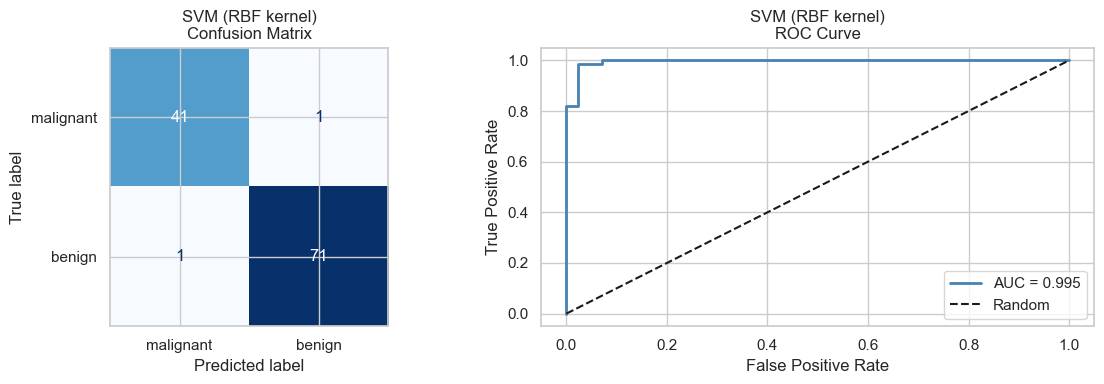

In [114]:
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
y_pred_svm = evaluate_classifier(
    'SVM (RBF kernel)', svm,
    X_bc_train_scaled, X_bc_test_scaled,
    y_bc_train, y_bc_test,
    target_names=bc.target_names,
    binary=True
)

### How to Read These Charts: SVM Confusion Matrix + ROC Curve

**Confusion Matrix:** Same 2x2 format as Naive Bayes. Look at the off-diagonal cells for mistakes. In cancer detection, the bottom-left cell (malignant cases called benign) is the most critical error.

**ROC Curve:** SVM with `probability=True` outputs probabilities, allowing us to draw the ROC curve.

**Comparing SVM to Naive Bayes:**
- SVM typically achieves a **higher AUC** because it directly optimizes the decision boundary rather than making probabilistic assumptions.
- A curve that hugs the top-left corner more tightly than Naive Bayes = SVM is better at separating the two classes.
- Check whether the SVM confusion matrix has fewer false negatives (missed cancers) — this is the clinically most important comparison.

In [115]:
# Compare SVM kernels
print("SVM Kernel Comparison on Breast Cancer Test Set:\n")
for kernel in ['linear', 'poly', 'rbf']:
    svc = SVC(kernel=kernel, C=1.0, random_state=42)
    svc.fit(X_bc_train_scaled, y_bc_train)
    acc = accuracy_score(y_bc_test, svc.predict(X_bc_test_scaled))
    print(f"  Kernel={kernel:6s}: Accuracy = {acc:.4f}")

SVM Kernel Comparison on Breast Cancer Test Set:

  Kernel=linear: Accuracy = 0.9737
  Kernel=poly  : Accuracy = 0.9123
  Kernel=rbf   : Accuracy = 0.9825


### How to Read This Output: SVM Kernel Comparison

This table shows accuracy for three different SVM kernels on the Breast Cancer test set.

- **linear:** Draws a straight hyperplane. Works best when the two classes can be cleanly separated by a straight boundary.
- **poly:** Uses a polynomial boundary — can capture curved separations.
- **rbf (Radial Basis Function):** The most flexible — creates a smooth, non-linear boundary that can wrap around complex class shapes.

**What to look for:**
- The kernel with the **highest accuracy** is the best choice for this dataset.
- If `rbf` wins by a large margin, the data has complex non-linear structure.
- If `linear` performs nearly as well as `rbf`, the data is largely linearly separable and the simpler kernel is preferred — faster and less risk of overfitting.

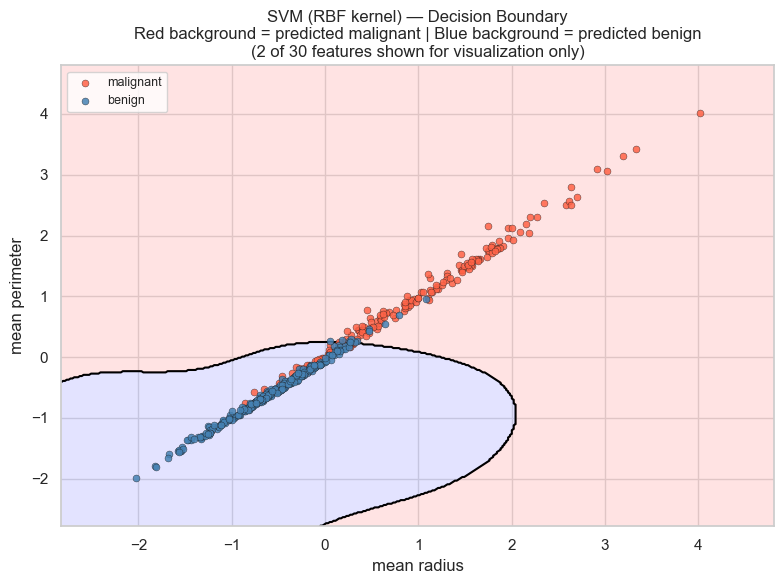

In [116]:
# Visualize SVM (RBF) decision boundary on 2 features
# target=0 -> malignant (red), target=1 -> benign (blue)
from matplotlib.colors import ListedColormap

feat_a, feat_b = 0, 2  # mean radius vs mean perimeter
X_2d = X_bc_train_scaled[:, [feat_a, feat_b]]

svm_2d = SVC(kernel='rbf', C=1.0, probability=True).fit(X_2d, y_bc_train)

h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.8, X_2d[:, 0].max() + 0.8
y_min, y_max = X_2d[:, 1].min() - 0.8, X_2d[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Consistent colour coding: 0 (malignant) -> light red, 1 (benign) -> light blue
cmap_bg = ListedColormap(['#FFBBBB', '#BBBBFF'])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)

# Draw a crisp decision boundary contour line
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)

# Scatter dots: malignant -> tomato, benign -> steelblue
for cls, col, name in zip([0, 1], ['tomato', 'steelblue'], bc.target_names):
    mask = y_bc_train.values == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=col, label=name, s=25,
                edgecolors='k', linewidths=0.3, alpha=0.85, zorder=3)

plt.xlabel(bc.feature_names[feat_a])
plt.ylabel(bc.feature_names[feat_b])
plt.title('SVM (RBF kernel) — Decision Boundary\n'
          'Red background = predicted malignant | Blue background = predicted benign\n'
          '(2 of 30 features shown for visualization only)')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### How to Read This Chart: SVM Decision Boundary

This chart shows the SVM's decision boundary using just **two features** so we can visualize it in 2D.

**Colour coding:**
- **Red dots** = malignant tumors | **Blue dots** = benign tumors
- **Light red background** = the model predicts malignant for any point in that region
- **Light blue background** = the model predicts benign for any point in that region

A red dot on a light red background = correct prediction. A red dot on a light blue background = misclassification (malignant called benign).

**The black boundary line** is where the model switches its prediction from one class to the other. With an RBF kernel this line is **curved**, allowing it to wrap around clusters of one class rather than being restricted to a straight line.

**What to look for:**
- How cleanly does the black line separate the red cluster from the blue cluster?
- Dots of one colour sitting inside the wrong background colour are misclassifications in this 2-feature projection.
- The clusters overlap more here than in the full 30-feature model — many of those overlapping points are correctly separated once the remaining 28 features are included.

> **Note:** This chart uses only 2 of the 30 features purely for visualization. The accuracy here will be lower than the full model's 98%+ — that is expected and not a bug.

---

# 6. Gradient Boosting Classifier (GBM)

**Dataset: Breast Cancer (Binary)**

## What Is It?

Gradient Boosting builds many small trees **sequentially** — each new tree focuses on correcting the mistakes of all previous trees.

> **Real-world analogy:** A team of doctors diagnosing a disease. The first doctor makes a diagnosis. The second specifically focuses on cases the first got wrong. The third focuses on what the first two missed. Together they form a very powerful team.

## Key Parameters

| Parameter | What It Controls |
|-----------|------------------|
| `n_estimators` | Number of trees (boosting rounds) |
| `learning_rate` | How much each tree contributes — lower = more conservative |
| `max_depth` | How complex each tree is |

## When to Use GBM?
- When you want **high accuracy** on tabular data
- When you are okay with **longer training time**

--- Gradient Boosting (GBM) ---
  Test Accuracy : 0.9561
  CV Accuracy   : 0.9560 +/- 0.0139

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



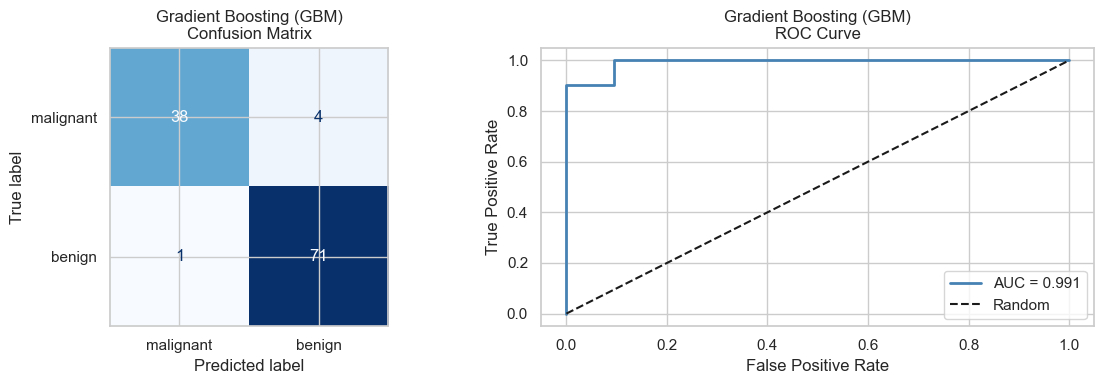

In [117]:
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
y_pred_gbm = evaluate_classifier(
    'Gradient Boosting (GBM)', gbm,
    X_bc_train_scaled, X_bc_test_scaled,
    y_bc_train, y_bc_test,
    target_names=bc.target_names,
    binary=True
)

### How to Read These Charts: GBM Confusion Matrix + ROC Curve

Same format as before — 2x2 confusion matrix and ROC curve for binary classification.

**Comparing GBM to SVM and Naive Bayes:**
- GBM is usually the strongest performer on tabular data. Look for a **higher AUC** and **fewer misclassifications** in the confusion matrix.
- Pay close attention to the **bottom-left cell (false negatives)** — these are missed malignant cases. A good model keeps this number as low as possible.
- If GBM's ROC curve sits higher (more toward the top-left) than the other models, it is doing a better overall classification job.

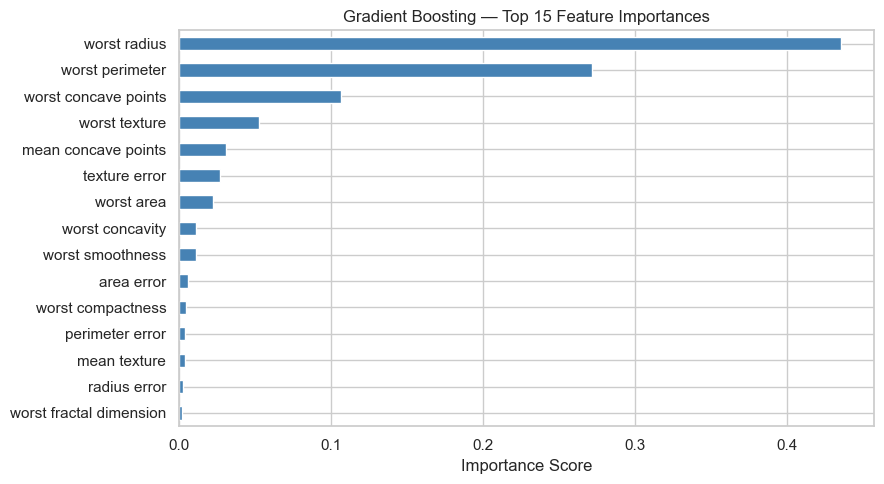


Feature importance tells us which measurements matter most for the prediction.


In [118]:
# Feature importance from GBM
fi_gbm = pd.Series(gbm.feature_importances_, index=bc.feature_names)
fi_top = fi_gbm.nlargest(15)

plt.figure(figsize=(9, 5))
fi_top.sort_values().plot(kind='barh', color='steelblue')
plt.title('Gradient Boosting — Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature importance tells us which measurements matter most for the prediction.")

### How to Read This Chart: Feature Importances

This **horizontal bar chart** shows which features the Gradient Boosting model found most useful for classification.

- **Each bar** represents one feature (a cell nucleus measurement).
- **Bar length** = importance score — how much this feature contributed to reducing classification error across all trees.
- Features are sorted so the **most important is at the top**.
- **Longer bar = more important feature.** A very short bar means that feature barely influenced any decision.

**What to look for:**
- Usually **2–5 features dominate** with much longer bars than the rest — these are the key drivers of the classification.
- Features with near-zero importance could potentially be removed without hurting performance much.
- Compare which features GBM considers important vs what the Naive Bayes feature distributions showed — they should roughly agree on the most informative measurements.

> **Clinical insight:** The top features in cancer classification often correspond to size and shape irregularities of cell nuclei — larger, more irregular cells tend to be malignant.

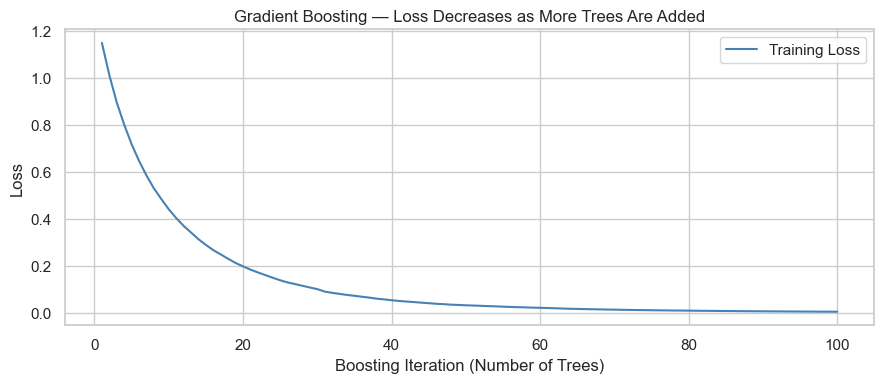

In [119]:
# Training loss curve
train_loss = gbm.train_score_

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(train_loss) + 1), train_loss, color='steelblue', label='Training Loss')
plt.xlabel('Boosting Iteration (Number of Trees)')
plt.ylabel('Loss')
plt.title('Gradient Boosting — Loss Decreases as More Trees Are Added')
plt.legend()
plt.tight_layout()
plt.show()

### How to Read This Chart: GBM Training Loss Curve

This **line chart** shows how the model's training error evolves as more trees are added.

- **x-axis** = the number of boosting iterations (trees added so far), from 1 to 100.
- **y-axis** = the training loss (error) — lower is better.
- **The blue line** = how the loss changes as each new corrective tree is added.

**What to look for:**
- The line should **drop steeply at first** — the first few trees eliminate the biggest, most obvious errors.
- As more trees are added, the drops get **smaller and smaller** — less room for improvement.
- Eventually the line **flattens out** — adding more trees is not helping much anymore.
- If the curve is still declining steeply at the right end, you might benefit from increasing `n_estimators`.
- If the curve flattens early, the current `n_estimators` is already sufficient.

> **Practical note:** This curve only shows training loss. To prevent overfitting, you'd also want to track validation loss. If validation loss starts rising while training loss keeps falling, the model is overfitting.

---

# 7. XGBoost (eXtreme Gradient Boosting)

**Dataset: Breast Cancer (Binary)**

## What Is It?

XGBoost is a **highly optimized, high-performance implementation of gradient boosting**. It builds on all the same principles as standard GBM, but adds:

1. **Built-in regularization (L1 and L2)** — prevents overfitting
2. **Parallelization** — uses all CPU cores for faster training
3. **Handles missing values automatically**
4. **Smarter tree pruning**

> **Real-world analogy:** If GBM is a team of doctors, XGBoost is the same team with better tools, better communication, and a much faster workflow.

## GBM vs XGBoost

| Feature | GBM | XGBoost |
|---------|-----|--------|
| Speed | Moderate | Much Faster |
| Regularization | Indirect | Built-in L1 + L2 |
| Missing value handling | Manual | Automatic |
| Industry usage | Common | Very widely used |

## When to Use XGBoost?
- For **competitive machine learning** / Kaggle problems
- Large **tabular datasets** where speed matters
- As a strong **production-ready** model

--- XGBoost ---
  Test Accuracy : 0.9474
  CV Accuracy   : 0.9670 +/- 0.0231

              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



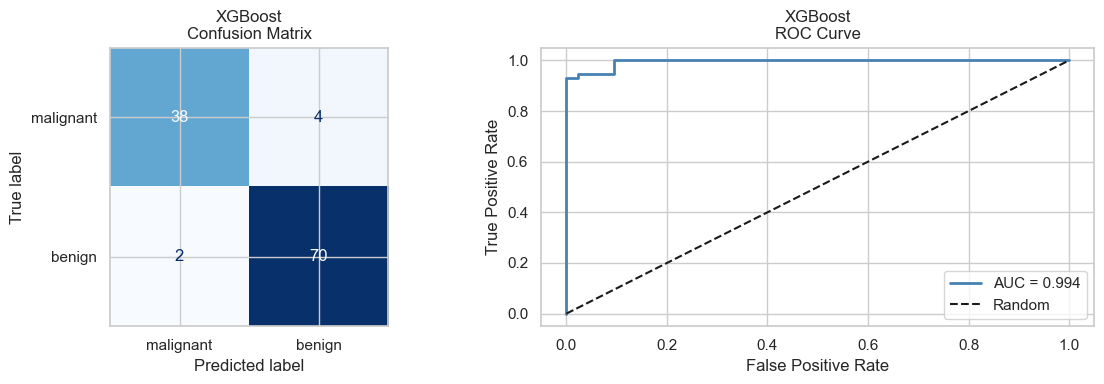

In [120]:
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        eval_metric='logloss',
        random_state=42
    )
    y_pred_xgb = evaluate_classifier(
        'XGBoost', xgb,
        X_bc_train_scaled, X_bc_test_scaled,
        y_bc_train, y_bc_test,
        target_names=bc.target_names,
        binary=True
    )
else:
    print("XGBoost not available. Please install with: pip install xgboost")

### How to Read These Charts: XGBoost Confusion Matrix + ROC Curve

Same 2x2 confusion matrix and ROC curve format.

**Comparing XGBoost to GBM:**
- XGBoost often achieves a **similar or slightly better AUC** compared to standard GBM, especially when regularization helps prevent overfitting on smaller datasets.
- Look at the **AUC score** on the ROC curve — a higher AUC than GBM means XGBoost is separating the classes better.
- If both models have similar confusion matrices, the key advantage of XGBoost in practice is its **speed** — it trains much faster on large datasets.
- Check whether XGBoost further reduces false negatives (missed cancers) compared to GBM — this is the most clinically meaningful improvement.

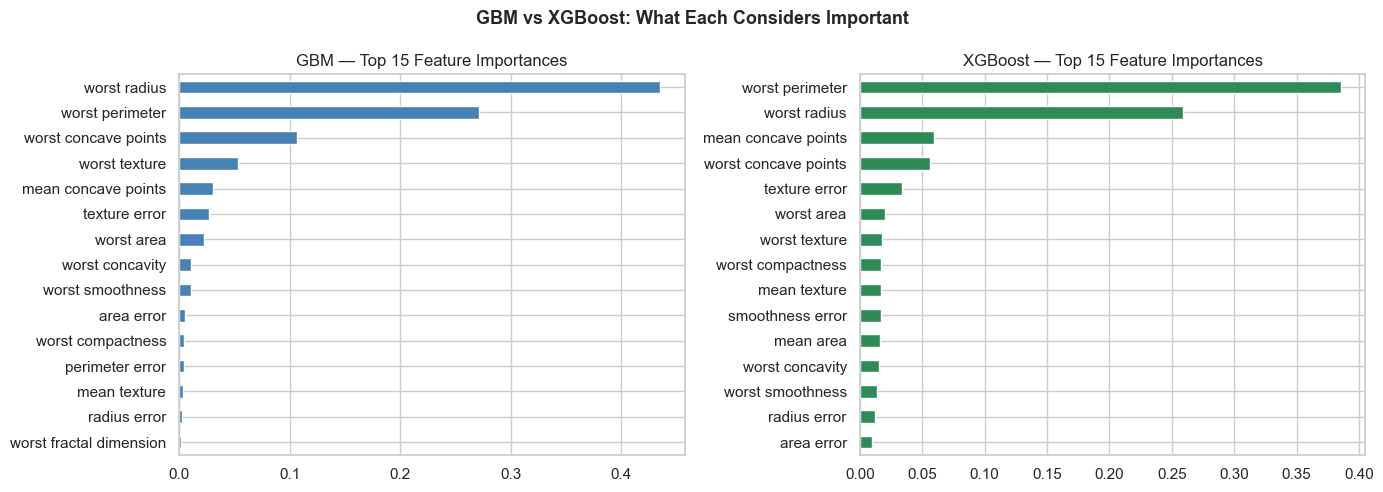

In [121]:
if XGBOOST_AVAILABLE:
    # XGBoost Feature Importance
    fi_xgb = pd.Series(xgb.feature_importances_, index=bc.feature_names)
    fi_top_xgb = fi_xgb.nlargest(15)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fi_top.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('GBM — Top 15 Feature Importances')

    fi_top_xgb.sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
    axes[1].set_title('XGBoost — Top 15 Feature Importances')

    plt.suptitle('GBM vs XGBoost: What Each Considers Important', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### How to Read This Chart: GBM vs XGBoost Feature Importances

This **side-by-side comparison** shows the top 15 features each model found most important — blue panel for GBM, green panel for XGBoost.

- **Each bar** represents a feature. Longer bar = more important.
- **Left panel (GBM):** What standard gradient boosting considers the most informative features.
- **Right panel (XGBoost):** What XGBoost considers the most informative features.

**What to look for:**
- Do both models **agree on the most important features**? If yes, those features are almost certainly genuinely important for predicting cancer.
- If they **disagree** on rankings, those features may be interchangeable — both are useful but neither is clearly dominant.
- XGBoost tends to **spread importance more evenly** across features due to its regularization — fewer features have extreme importance scores.
- GBM can sometimes place **very high importance on just 1–2 features**, making it more sensitive to those specific measurements.

> **Practical use:** If you wanted to build a simpler clinical tool, look at where both models agree — those are the measurements worth focusing on.

---

# Final Comparison — All Classification Models

## Overall Performance Summary

Let's bring all results together. Note that models trained on different datasets (Wine vs Breast Cancer) **cannot be directly compared** — this is just to show all results in one place.

In [122]:
results_df_clf = pd.DataFrame(clf_results).T.reset_index()
results_df_clf.columns = ['Model'] + list(results_df_clf.columns[1:])
results_df_clf = results_df_clf.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("Classification Model Summary (sorted by Test Accuracy):\n")
print(results_df_clf.to_string(index=False))

Classification Model Summary (sorted by Test Accuracy):

                  Model  Accuracy  CV Mean  CV Std    AUC
                    QDA    1.0000   0.9788  0.0173    NaN
   KNN Classifier (k=7)    1.0000   0.9579  0.0405    NaN
       SVM (RBF kernel)    0.9825   0.9714  0.0179 0.9950
Gradient Boosting (GBM)    0.9561   0.9560  0.0139 0.9907
                XGBoost    0.9474   0.9670  0.0231 0.9944
                    LDA    0.9444   0.9929  0.0143    NaN
   Gaussian Naive Bayes    0.9298   0.9319  0.0044 0.9868


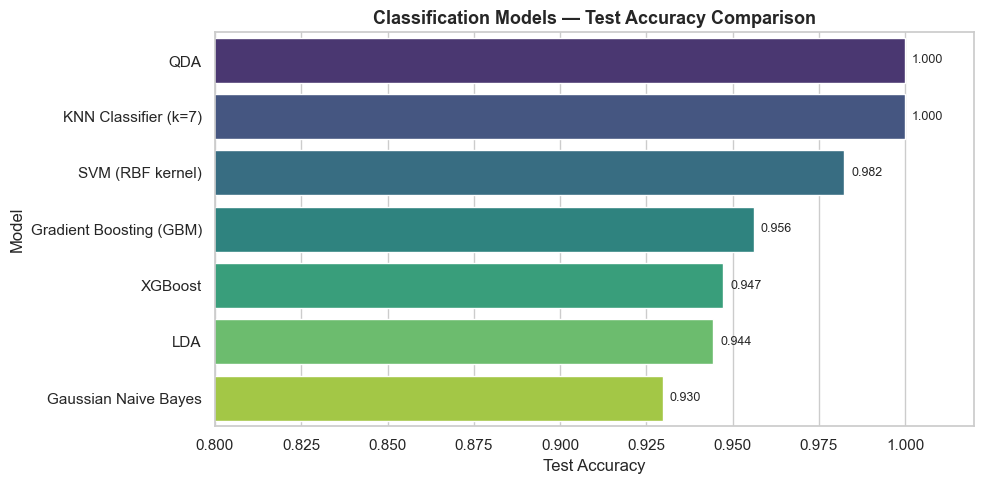

In [123]:
# Accuracy bar chart
plt.figure(figsize=(10, 5))
bars = sns.barplot(data=results_df_clf, x='Accuracy', y='Model', palette='viridis')
plt.title('Classification Models — Test Accuracy Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Test Accuracy')
plt.xlim(0.8, 1.02)
for bar, val in zip(bars.patches, results_df_clf['Accuracy']):
    bars.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
              f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### How to Read This Chart: Final Model Accuracy Comparison

This **horizontal bar chart** ranks all classification models by their test accuracy.

- **Each bar** represents one model. Longer bar = higher accuracy.
- **The number at the end of each bar** is the exact test accuracy (e.g., 0.974 = 97.4% correct predictions).
- Models are sorted from **best to worst** (top = best).
- The x-axis starts at 0.8 (80%) since all models are expected to perform well on these clean datasets.

**What to look for:**
- Is there a **clear winner**, or are most models clustered closely together?
- A small gap between models means any of them would work well in practice — choose based on interpretability or speed.
- A large gap means the top model is genuinely better and worth the added complexity.

**Important caveat:**
- Models on Wine and Breast Cancer **cannot be directly compared** on accuracy alone — they are solving different problems with different difficulty levels.
- The Wine dataset is smaller and easier to classify (3 well-separated classes), so models may score higher there.
- Always compare models trained **on the same dataset** for a fair evaluation.

> **Remember:** Accuracy is just one metric. In medical settings, always also check recall (catching all cancer cases) and precision (avoiding unnecessary alarms). High accuracy alone does not guarantee a clinically safe model.

---

# Summary and Key Takeaways

## Model Guide

| Model | Dataset | Strength | Best Use Case |
|-------|---------|----------|---------------|
| **LDA** | Wine | Linear boundaries + dimensionality reduction | Well-separated classes; interpretable projections |
| **QDA** | Wine | Flexible curved boundaries | Classes with different covariance structures |
| **Gaussian Naive Bayes** | Breast Cancer | Fast, probabilistic, interpretable | Quick baseline; near-independent features |
| **KNN** | Wine | No assumptions; local patterns | Small-medium data; no strong distributional assumptions |
| **SVM** | Breast Cancer | Maximum margin; kernel trick | High-dimensional data; complex non-linear boundaries |
| **Gradient Boosting** | Breast Cancer | Sequentially correct errors | Tabular data; high-accuracy requirement |
| **XGBoost** | Breast Cancer | GBM + speed + regularization | Large tabular data; production-grade performance |

---

## Evaluation Metrics Quick Reference

| Metric | What It Tells You | When to Prioritize |
|--------|------------------|-------------------|
| **Accuracy** | % of all predictions correct | Balanced datasets |
| **Precision** | Of all predicted positives, how many are actually positive? | When false positives are costly (spam filters) |
| **Recall** | Of all actual positives, how many did we catch? | When false negatives are costly (disease diagnosis) |
| **F1-Score** | Harmonic mean of precision and recall | Imbalanced datasets |
| **ROC-AUC** | Overall ability to distinguish classes | Binary classification; threshold-independent |

---

## The Golden Rule for Classification

> **Accuracy alone is misleading.** Always look at precision, recall, and the confusion matrix — especially if your classes are imbalanced. A model that predicts "benign" for every tumor might have 63% accuracy but would be medically dangerous.

---

## What's Next?

- Explore **regression models** in the companion notebook: `linear_regression_models.ipynb`
- Explore **ensemble methods** (Random Forest, Bagging, Stacking) in the dedicated ensemble models repository
- Try **GridSearchCV** to systematically find the best hyperparameters for each model